<a href="https://colab.research.google.com/github/KarAnalytics/code_demos/blob/main/Video_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG with Video: Visual Question-Answering over Video Frames

This notebook demonstrates **Retrieval-Augmented Generation (RAG)** where the knowledge source is a **video**. Instead of searching documents or databases, we extract frames from a video, index them with CLIP embeddings, and retrieve the most relevant frames to answer natural-language questions.

**How it works:**
1. Generate a short **synthetic video** (animated product showcase — no external data needed).
2. Extract **keyframes** at regular intervals.
3. Compute **CLIP embeddings** for each frame to create a searchable index.
4. Given a natural-language question, retrieve the most relevant frame(s) via cosine similarity.
5. Send retrieved frames to a **multimodal LLM** for a grounded, natural-language answer.

**Learning goals:**
- Understand how RAG applies to temporal/video data
- See how frame extraction converts video into an image retrieval problem
- Practice grounding LLM output on visual evidence from specific moments in a video
- Compare answers with and without video context



Store whichever API keys you have in Colab Secrets (or a local `.env` file):
`GEMINI_API_KEY`, `OLLAMA_API_KEY`, `XAI_API_KEY`, `GROQ_API_KEY`, `HF_TOKEN`, `COHERE_API_KEY`, `OPENROUTER_API_KEY`

In [1]:
!pip install -q google-genai Pillow==11.0.0 transformers==4.46.3 matplotlib opencv-python-headless git+https://github.com/KarAnalytics/llm_cascade.git

## 1) Imports and Provider Helpers (7-Vendor Cascade)

We use **OpenCV** to create and read video, **CLIP** to embed frames and text queries into the same vector space, and **PIL/Pillow** for image display. If you have already worked through the Image RAG notebook, you will recognize most of these imports -- and that is the point. Video RAG is fundamentally the same pattern as Image RAG, applied to a different modality. The main new ingredient is OpenCV, which handles the mechanics of extracting individual frames from a video file.

In [2]:
# =============================================================================
# Imports + LLM Cascade
# =============================================================================

import os
import base64
import io
import math
import numpy as np
from pathlib import Path

import cv2
from PIL import Image, ImageDraw, ImageFont
from google import genai
from google.genai import types as genai_types

from llm_cascade import get_cascade
from llm_cascade.providers import _get_key

llm = get_cascade()


def has_llm_provider():
    """True if llm_cascade has at least one provider configured."""
    return True  # get_cascade() already validates


def generate_text(prompt, system_prompt=None):
    """
    Send a text prompt through llm_cascade.
    Returns (response_text, provider_name).
    """
    resp = llm.generate(prompt, system_prompt=system_prompt)
    return resp.text, f"{resp.provider}/{resp.model}"


print(f"LLM cascade ready.")


LLM Cascade - available providers:
  + Gemini           model=gemini-2.5-flash
  + Ollama           model=kimi-k2.5:cloud
  + HuggingFace      model=meta-llama/Llama-3.3-70B-Instruct
  + Cohere           model=command-a-03-2025
  + OpenRouter       model=meta-llama/llama-3.3-70b-instruct:free
  + OpenAI           model=gpt-4o-mini
Not configured (skipped):
  - Groq             (set GROQ_API_KEY)
  - Grok (xAI)       (set XAI_API_KEY)
LLM cascade ready.


## 2) Generate a Synthetic Video

We create a short animated video that simulates a **product showcase reel**. The video has distinct scenes, each showing a different product with visual attributes that change over time.

This keeps the demo self-contained (no external video files needed) while providing enough visual variety to test retrieval.

| Time (sec) | Scene | Content |
|---|---|---|
| 0–3 | Title card | "Acme Corp Product Showcase" on blue background |
| 3–7 | Product 1 | Red circle — "Widget Alpha" with price |
| 7–11 | Product 2 | Green triangle — "Gadget Beta" with price |
| 11–15 | Product 3 | Blue square — "Tool Gamma" with price |
| 15–19 | Product 4 | Orange diamond — "Device Delta" with price |
| 19–22 | Closing card | "Thank you! Visit acme-corp.example.com" |

In [3]:
VIDEO_PATH = "product_showcase.mp4"
FPS = 10
WIDTH, HEIGHT = 640, 480

# Scene definitions
SCENES = [
    {
        "name": "title",
        "start": 0, "end": 3,
        "label": "Acme Corp\nProduct Showcase 2026",
        "bg_color": (40, 60, 120),
        "shape": None,
        "product": None,
    },
    {
        "name": "widget_alpha",
        "start": 3, "end": 7,
        "label": "Widget Alpha — $12.99",
        "bg_color": (255, 245, 238),
        "shape": "circle",
        "shape_color": (231, 76, 60),
        "product": {"name": "Widget Alpha", "price": 12.99, "color": "red", "shape": "circle"},
    },
    {
        "name": "gadget_beta",
        "start": 7, "end": 11,
        "label": "Gadget Beta — $8.75",
        "bg_color": (240, 255, 240),
        "shape": "triangle",
        "shape_color": (46, 204, 113),
        "product": {"name": "Gadget Beta", "price": 8.75, "color": "green", "shape": "triangle"},
    },
    {
        "name": "tool_gamma",
        "start": 11, "end": 15,
        "label": "Tool Gamma — $34.99",
        "bg_color": (235, 245, 255),
        "shape": "square",
        "shape_color": (52, 152, 219),
        "product": {"name": "Tool Gamma", "price": 34.99, "color": "blue", "shape": "square"},
    },
    {
        "name": "device_delta",
        "start": 15, "end": 19,
        "label": "Device Delta — $19.25",
        "bg_color": (255, 248, 230),
        "shape": "diamond",
        "shape_color": (230, 126, 34),
        "product": {"name": "Device Delta", "price": 19.25, "color": "orange", "shape": "diamond"},
    },
    {
        "name": "closing",
        "start": 19, "end": 22,
        "label": "Thank you!\nVisit acme-corp.example.com",
        "bg_color": (40, 60, 120),
        "shape": None,
        "product": None,
    },
]


def draw_frame_pil(scene, t, width=WIDTH, height=HEIGHT):
    """Draw a single video frame for a given scene and time offset using PIL."""
    bg = scene["bg_color"]
    img = Image.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(img)

    # Load font
    try:
        font_large = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
        font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)
    except (OSError, IOError):
        try:
            font_large = ImageFont.truetype("arial.ttf", 28)
            font_small = ImageFont.truetype("arial.ttf", 22)
        except (OSError, IOError):
            font_large = ImageFont.load_default()
            font_small = font_large

    cx, cy = width // 2, height // 2

    if scene["shape"] is None:
        # Title or closing card — centered text
        text_color = (255, 255, 255)
        lines = scene["label"].split("\n")
        total_h = len(lines) * 40
        y_start = cy - total_h // 2
        for j, line in enumerate(lines):
            bbox = draw.textbbox((0, 0), line, font=font_large)
            tw = bbox[2] - bbox[0]
            draw.text(((width - tw) // 2, y_start + j * 40), line, fill=text_color, font=font_large)
    else:
        # Product scene — animated shape (gentle bounce)
        bounce = int(15 * math.sin(t * 3))
        shape_cy = cy - 30 + bounce
        r = 80
        color = scene["shape_color"]

        if scene["shape"] == "circle":
            draw.ellipse([cx - r, shape_cy - r, cx + r, shape_cy + r], fill=color, outline=(0, 0, 0), width=3)
        elif scene["shape"] == "square":
            draw.rectangle([cx - r, shape_cy - r, cx + r, shape_cy + r], fill=color, outline=(0, 0, 0), width=3)
        elif scene["shape"] == "triangle":
            pts = [(cx, shape_cy - r), (cx - r, shape_cy + r), (cx + r, shape_cy + r)]
            draw.polygon(pts, fill=color, outline=(0, 0, 0), width=3)
        elif scene["shape"] == "diamond":
            pts = [(cx, shape_cy - r), (cx + r, shape_cy), (cx, shape_cy + r), (cx - r, shape_cy)]
            draw.polygon(pts, fill=color, outline=(0, 0, 0), width=3)

        # Product label at top
        bbox = draw.textbbox((0, 0), scene["label"], font=font_small)
        tw = bbox[2] - bbox[0]
        draw.text(((width - tw) // 2, 20), scene["label"], fill=(30, 30, 30), font=font_small)

        # Timestamp at bottom-right
        ts_text = f"t={t:.1f}s"
        draw.text((width - 90, height - 30), ts_text, fill=(120, 120, 120), font=font_small)

    return img


def generate_video(path, scenes, fps, width=WIDTH, height=HEIGHT):
    """Generate an MP4 video from scene definitions."""
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(path, fourcc, fps, (width, height))

    for scene in scenes:
        duration = scene["end"] - scene["start"]
        n_frames = int(duration * fps)
        for i in range(n_frames):
            t = scene["start"] + i / fps
            pil_img = draw_frame_pil(scene, t, width, height)
            # Convert PIL (RGB) -> OpenCV (BGR)
            frame = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
            writer.write(frame)

    writer.release()


generate_video(VIDEO_PATH, SCENES, FPS)
total_duration = SCENES[-1]["end"]
file_size_kb = Path(VIDEO_PATH).stat().st_size / 1024
print(f"Video generated: '{VIDEO_PATH}'")
print(f"  Duration: {total_duration}s | FPS: {FPS} | Resolution: {WIDTH}x{HEIGHT} | Size: {file_size_kb:.0f} KB")

Video generated: 'product_showcase.mp4'
  Duration: 22s | FPS: 10 | Resolution: 640x480 | Size: 260 KB


## 3) Extract Keyframes from the Video

Here is the crucial insight behind Video RAG: we do not try to process the video as a continuous stream. Instead, we **sample keyframes** at regular intervals and treat each one as an independent image. This converts the temporal video retrieval problem into the familiar image retrieval problem we already solved in the Image RAG notebook.

Why not process the full video? A 22-second video at 10 FPS contains 220 frames, most of which are nearly identical to their neighbors. Processing every frame would waste compute and storage without improving retrieval quality. By extracting one frame per second, we capture each scene while keeping our index compact. For longer or faster-paced videos you would adjust this sampling rate -- the tradeoff is always between coverage (catching brief but important moments) and efficiency (keeping the index manageable).

In [4]:
def extract_keyframes(video_path, interval_sec=1.0):
    """Extract frames from a video at a fixed time interval.

    Returns a list of dicts: {"timestamp": float, "image": PIL.Image}
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps
    frame_interval = int(fps * interval_sec)

    frames = []
    frame_idx = 0
    while True:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR -> RGB -> PIL
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)
        timestamp = frame_idx / fps
        frames.append({"timestamp": timestamp, "image": pil_img})
        frame_idx += frame_interval

    cap.release()
    return frames, duration


keyframes, video_duration = extract_keyframes(VIDEO_PATH, interval_sec=1.0)
print(f"Extracted {len(keyframes)} keyframes from {video_duration:.1f}s video (1 frame/sec)")
print(f"Timestamps: {[f'{kf["timestamp"]:.1f}s' for kf in keyframes]}")

Extracted 22 keyframes from 22.0s video (1 frame/sec)
Timestamps: ['0.0s', '1.0s', '2.0s', '3.0s', '4.0s', '5.0s', '6.0s', '7.0s', '8.0s', '9.0s', '10.0s', '11.0s', '12.0s', '13.0s', '14.0s', '15.0s', '16.0s', '17.0s', '18.0s', '19.0s', '20.0s', '21.0s']


### Preview Keyframes

The grid below shows every other keyframe from our 22-second video. You can see the distinct scenes: a title card, four product showcases (each with a different colored shape), and a closing card. Each of these frames will become an entry in our CLIP index, tagged with its timestamp so we can tell the user not just *what* was found but *when* in the video it appeared.

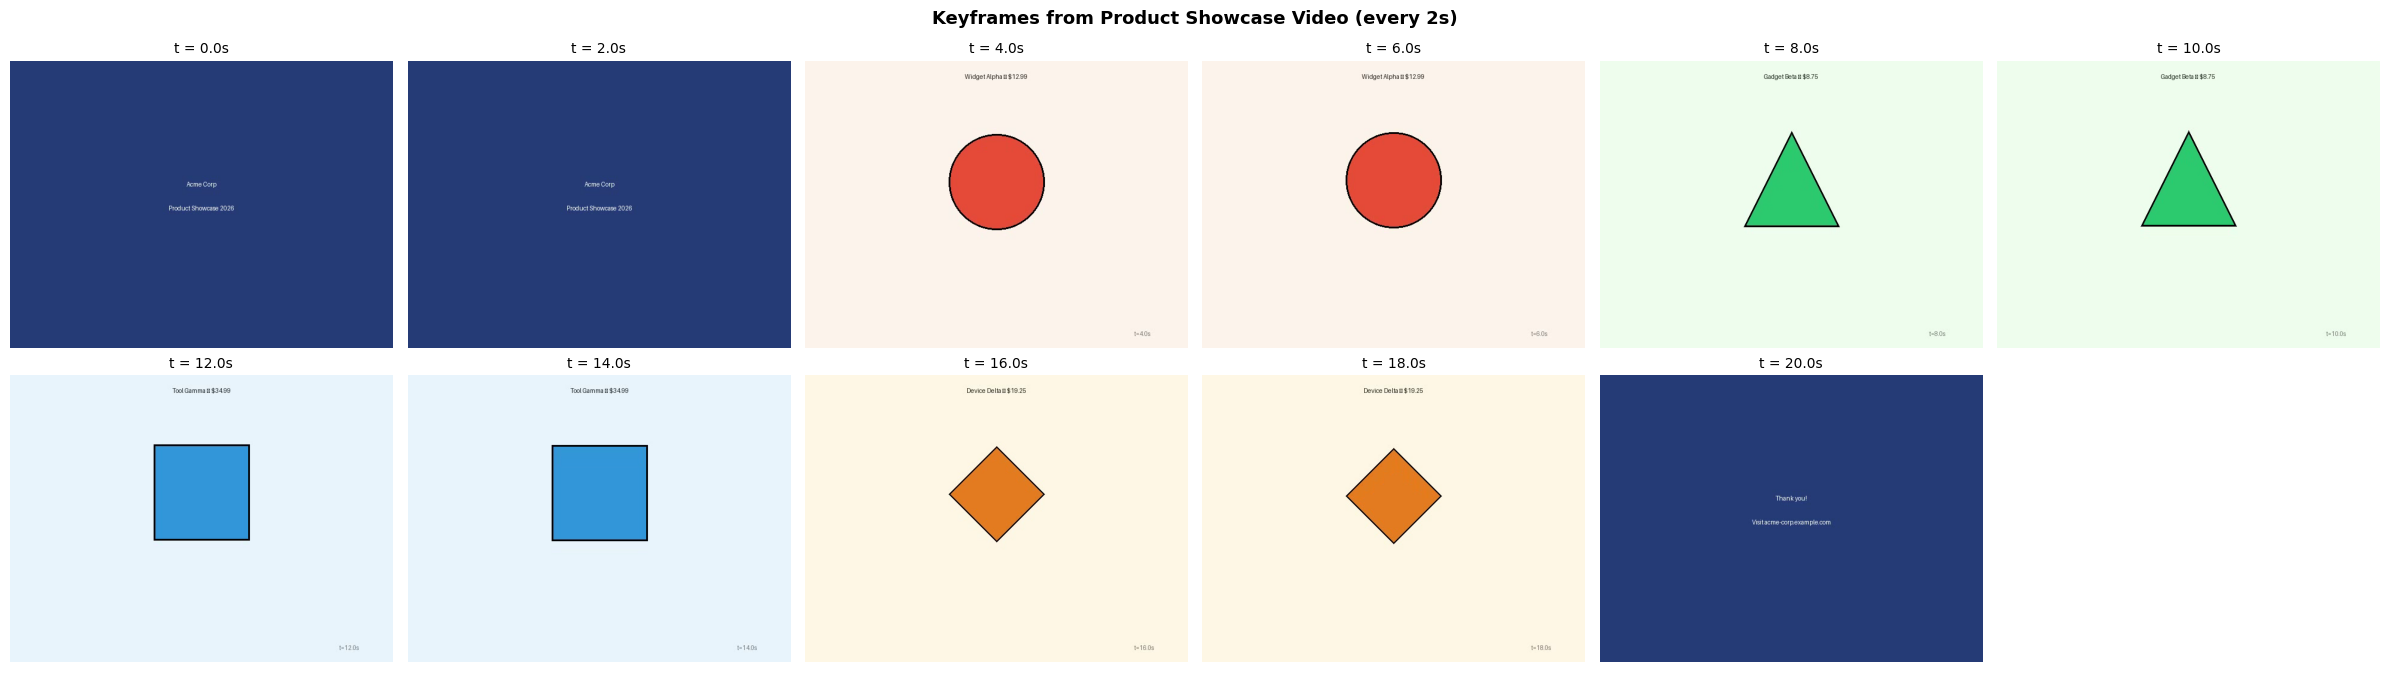

In [5]:
import matplotlib.pyplot as plt

# Show a subset of keyframes (every other frame to save space)
display_frames = keyframes[::2]
n = len(display_frames)
cols = min(n, 6)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]
for i, ax in enumerate(axes_flat):
    if i < n:
        ax.imshow(display_frames[i]["image"])
        ax.set_title(f"t = {display_frames[i]['timestamp']:.1f}s", fontsize=10)
    ax.axis("off")
fig.suptitle("Keyframes from Product Showcase Video (every 2s)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4) Build the Frame Index with CLIP Embeddings

Just like in Image RAG, we use **CLIP** to embed each keyframe into a 512-dimensional vector. At query time we embed the user's text query with the same model and find the closest frame(s) by cosine similarity. The embedding and retrieval code is nearly identical to what we wrote for static images -- because once you extract keyframes, a video *is* just a collection of images.

The key difference from Image RAG is that each frame also carries a **timestamp**. This temporal metadata transforms a simple "which image matches?" answer into a richer "at what point in the video can you find this?" answer. Timestamps are what make Video RAG genuinely useful for applications like meeting recording search, surveillance review, or training video navigation.

In [6]:
from transformers import CLIPProcessor, CLIPModel
import torch

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

print(f"CLIP model loaded: {CLIP_MODEL_NAME}")
print(f"Embedding dimension: {clip_model.config.projection_dim}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded: openai/clip-vit-base-patch32
Embedding dimension: 512


In [7]:
def embed_frames(keyframes, model, processor):
    """Compute CLIP embeddings for a list of keyframe images."""
    images = [kf["image"].convert("RGB") for kf in keyframes]
    inputs = processor(images=images, return_tensors="pt", padding=True)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    return embeddings.numpy()


def embed_text(query, model, processor):
    """Compute CLIP embedding for a text query."""
    inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        embeddings = model.get_text_features(**inputs)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    return embeddings.numpy()


# Build the frame index
frame_embeddings = embed_frames(keyframes, clip_model, clip_processor)
print(f"Frame index built: {frame_embeddings.shape[0]} frames, {frame_embeddings.shape[1]}-dim embeddings")

Frame index built: 22 frames, 512-dim embeddings


Our frame index is now ready: 22 keyframes, each represented as a 512-dimensional CLIP vector. Notice how the code above is almost identical to the image embedding code from the Image RAG notebook -- the only difference is that our "images" come from video frames rather than from files on disk. This reuse of the same CLIP infrastructure across modalities is a powerful design pattern: once you can convert any data source into images, you get cross-modal search for free.

## 5) Frame Retrieval — the "Retrieval" in Video RAG

Given a text query, we:
1. Embed the query with CLIP's text encoder.
2. Compute **cosine similarity** against all frame embeddings.
3. Return the top-k most similar frames with their timestamps.

The timestamp tells us *when* in the video the answer can be found.

In [ ]:
## 6) Answer Generation -- Multimodal LLM with Retrieved Frames

The multimodal LLM receives the **retrieved frames** as actual images, along with **metadata** about each frame (timestamp, scene name, product info) and the user's **question**. It generates an answer grounded on what it can see in the frames, referencing specific timestamps to tell the user exactly where in the video the relevant content appears.

This is where Video RAG delivers something that pure text RAG never could: temporal grounding. Instead of just saying "the red product costs $12.99," the system can say "at t=4.0s in the video, you can see Widget Alpha, a red circle priced at $12.99." That temporal precision is what makes Video RAG valuable for applications like searching through hours of meeting recordings or surveillance footage.

We also provide a "without RAG" function that answers with no video context, so we can compare the grounded answer against a baseline that has never seen our video.

## 6) Answer Generation — Multimodal LLM with Retrieved Frames

The multimodal LLM receives:
- The **retrieved frames** (as images)
- **Metadata** about each frame (timestamp, scene, product info)
- The user's **question**

It generates an answer grounded on what it can see in the frames and the associated timestamps.

We also provide a "without RAG" function that answers with no video context.

In [9]:
def build_frame_context(results):
    """Build a text description of retrieved frames."""
    lines = ["Retrieved video frames (ranked by visual similarity):"]
    for r in results:
        prod = r["product"]
        prod_str = (
            f"{prod['name']}: {prod['color']} {prod['shape']}, ${prod['price']:.2f}"
            if prod else "(title/closing card)"
        )
        lines.append(
            f"  #{r['rank']} timestamp={r['timestamp']:.1f}s, scene={r['scene_name']}, "
            f"product={prod_str}, similarity={r['similarity']:.3f}"
        )
    return "\n".join(lines)


VIDEO_RAG_SYSTEM_PROMPT = (
    "You are a helpful video analyst. You are given keyframes extracted from a product "
    "showcase video, along with their timestamps and metadata. Answer the user's question "
    "based on what you can SEE in the frames and the provided metadata. Reference specific "
    "timestamps when relevant (e.g., 'at t=5.0s'). If the frames do not contain enough "
    "information, say so. Do not invent products or details not shown."
)


def generate_answer_with_frames(question, results):
    """Send retrieved frames + metadata to an LLM.

    Gemini gets native multimodal (images + text) if GEMINI_API_KEY is set.
    Otherwise falls back to llm_cascade with text-only metadata context.
    """
    context_text = build_frame_context(results)

    # Try Gemini multimodal first (needs actual images)
    gemini_key = _get_key("GEMINI_API_KEY")
    if gemini_key:
        try:
            client = genai.Client(api_key=gemini_key)
            parts = []
            parts.append(genai_types.Part.from_text(
                text=f"{VIDEO_RAG_SYSTEM_PROMPT}\n\n{context_text}\n\nQUESTION: {question}"
            ))
            for r in results:
                buf = io.BytesIO()
                r["image"].save(buf, format="PNG")
                parts.append(genai_types.Part.from_bytes(data=buf.getvalue(), mime_type="image/png"))
            resp = client.models.generate_content(model="gemini-2.5-flash", contents=parts)
            return resp.text, "Gemini (multimodal)"
        except Exception as exc:
            print(f"  [Gemini multimodal] failed: {exc} -- falling back to text-only cascade")

    # Fallback: text-only via llm_cascade
    prompt = f"{context_text}\n\nQUESTION: {question}"
    resp = llm.generate(prompt, system_prompt=VIDEO_RAG_SYSTEM_PROMPT)
    return resp.text, f"{resp.provider}/{resp.model}"


def generate_answer_without_rag(question):
    """Direct LLM answer with NO video frames."""
    return generate_text(question)


print("Answer generation functions ready (llm_cascade).")


Answer generation functions ready (llm_cascade).


## 7) Full Video RAG Pipeline

Putting it all together into a single callable function. The pipeline mirrors what we built for Image RAG -- embed the query, retrieve relevant frames, generate an answer -- but now each result includes a timestamp that grounds the answer in the video's timeline. This is the complete Video RAG loop: from a natural-language question to a temporally grounded, visually informed answer.

In [10]:
def answer_with_video_rag(question, top_k=3):
    """Full Video RAG: extract frames -> CLIP retrieval -> multimodal LLM answer."""
    print(f"  [Step 1] Embedding query with CLIP ...")
    results = retrieve_frames(
        question, frame_embeddings, keyframes, clip_model, clip_processor, top_k=top_k,
    )
    print(f"  [Step 2] Retrieved {len(results)} frame(s):")
    for r in results:
        prod_name = r['product']['name'] if r['product'] else '(card)'
        print(f"           #{r['rank']} t={r['timestamp']:.1f}s — {prod_name} (sim={r['similarity']:.3f})")

    print(f"  [Step 3] Generating multimodal answer ...")
    answer, provider = generate_answer_with_frames(question, results)
    print(f"  [Step 4] Answer generated (provider: {provider})")
    return answer, results, provider


print("Video RAG pipeline ready.")

Video RAG pipeline ready.


## 8) Run End-to-End Examples: With RAG vs. Without RAG

We test questions about the product showcase video and compare:
- **With Video RAG:** CLIP retrieves the relevant frame(s), multimodal LLM answers with visual + temporal grounding
- **Without RAG:** LLM answers with no video context — it knows nothing about our product showcase

Watch how the without-RAG answers either refuse to answer (no context) or hallucinate product details.


Q1. What is the red product shown in the video and how much does it cost?

--- WITH VIDEO RAG ---
  [Step 1] Embedding query with CLIP ...
  [Step 2] Retrieved 3 frame(s):
           #1 t=6.0s — Widget Alpha (sim=0.255)
           #2 t=4.0s — Widget Alpha (sim=0.251)
           #3 t=5.0s — Widget Alpha (sim=0.250)
  [Step 3] Generating multimodal answer ...
  [Step 4] Answer generated (provider: Gemini (multimodal))


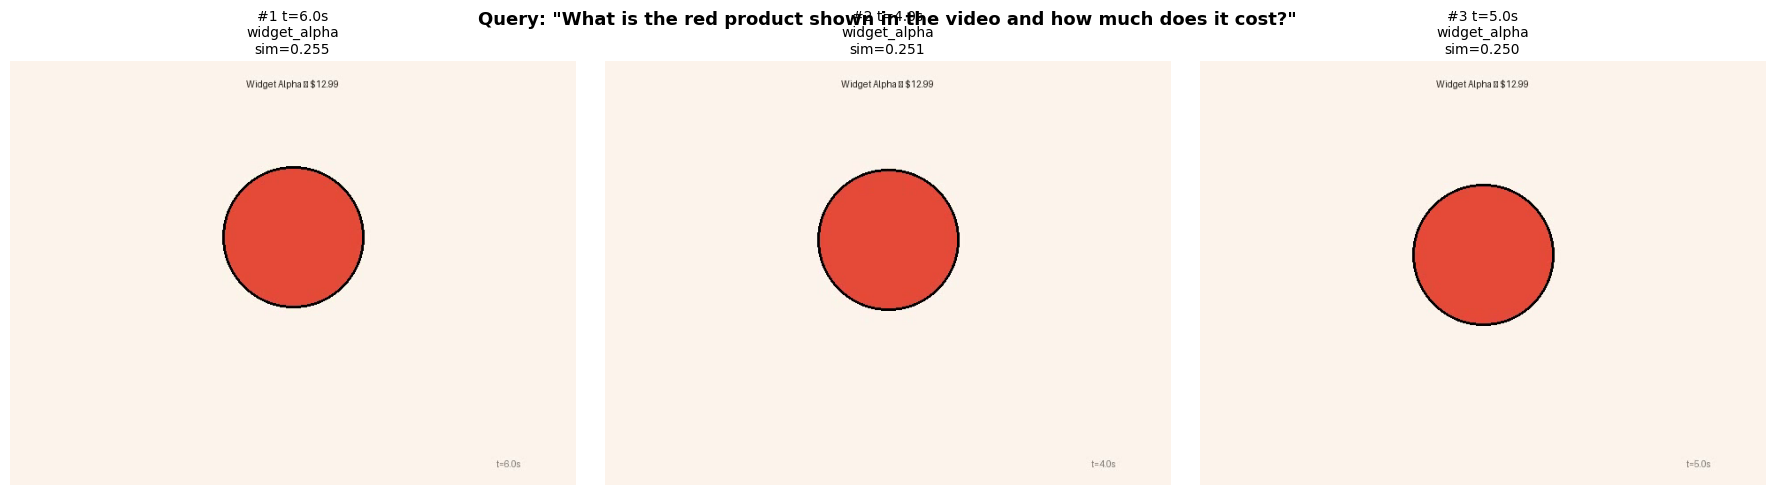


  Answer (provider: Gemini (multimodal)):
Based on the video frames and their metadata:

The red product shown in the video is **Widget Alpha**, which is depicted as a red circle (visible at t=6.0s, t=4.0s, and t=5.0s). It costs **$12.99**, as displayed in the text overlay in each frame and confirmed by the metadata.

--- WITHOUT RAG (LLM knowledge only) ---
  [Gemini] unavailable, trying next...
  [Response from Ollama / kimi-k2.5:cloud]
  Answer (provider: Ollama/kimi-k2.5:cloud):
I don't see any video attached to your message. I don't have the ability to view videos, images, or access external links that you might be watching on your screen.

To help you find the product and its price, could you please provide:

1. **A description of the product** - What does it look like? What is it used for? (e.g., a red kitchen gadget, tool, electronic device, beauty product, etc.)
2. **The name of the video or creator** - Where did you see it? (YouTube, TikTok, Instagram, etc.)
3. **Any visible

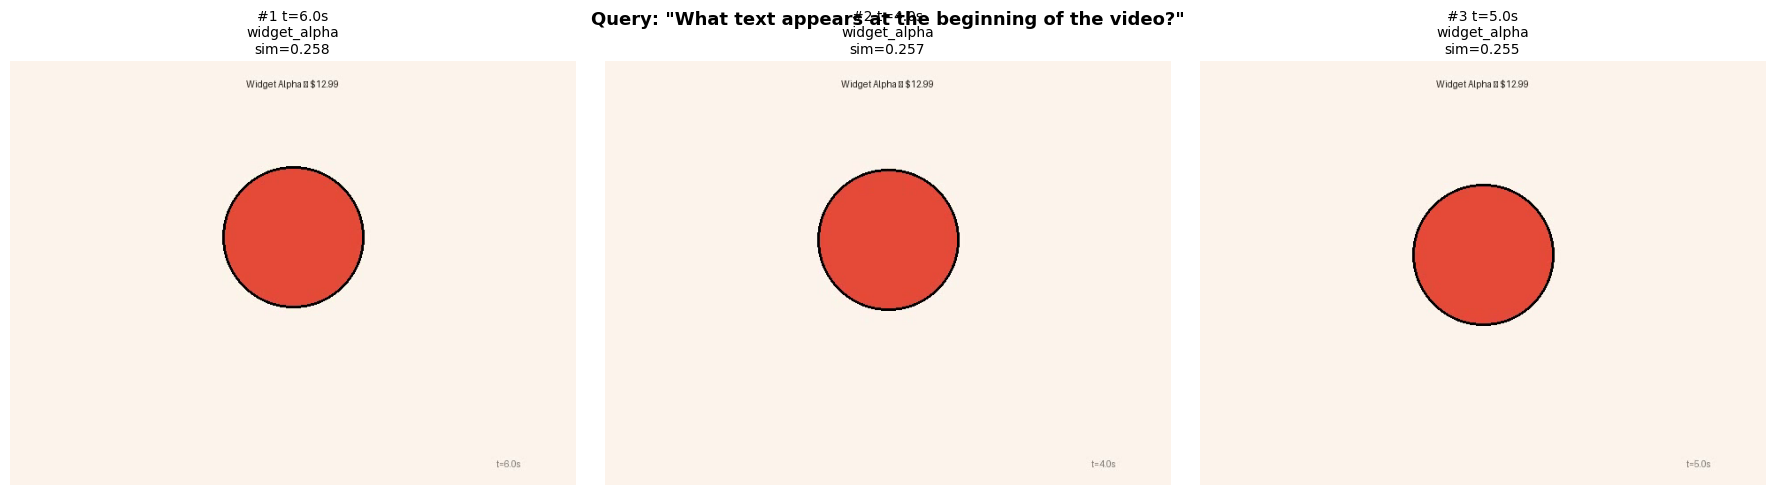


  Answer (provider: Ollama/kimi-k2.5:cloud):
Based on the provided frames, I cannot determine what text appears at the beginning of the video. The retrieved frames are from timestamps **t=4.0s**, **t=5.0s**, and **t=6.0s**, but none show the opening/start of the video (t=0s or early timestamps). 

If you need information about the beginning, please provide frames from earlier timestamps (close to 0.0s).

--- WITHOUT RAG (LLM knowledge only) ---
  [Gemini] unavailable, trying next...
  [Response from Ollama / kimi-k2.5:cloud]
  Answer (provider: Ollama/kimi-k2.5:cloud):
I don't see a video attached to your message, and I don't have access to external video links or the ability to view video content. 

Could you please clarify which video you're referring to? For example:

- **A specific YouTube/TikTok video** (please share the title or link)
- **A video from a previous conversation**
- **A popular meme or viral video** (describe what happens in it)
- **A movie or TV show** (name the ti

In [11]:
questions = [
    "What is the red product shown in the video and how much does it cost?",
    #"At what point in the video does the green triangle appear?",
    #"What is the most expensive product in this showcase video?",
    #"What shape is the orange product?",
    "What text appears at the beginning of the video?",
]


def preview(text, max_len=800):
    text = text or ""
    return text[:max_len] + ("..." if len(text) > max_len else "")


if not has_llm_provider():
    print("Error: No LLM API key configured. Set at least one API key in Colab Secrets.")
else:
    for i, q in enumerate(questions, start=1):
        print("\n" + "=" * 80)
        print(f"Q{i}. {q}")
        print("=" * 80)

        # --- WITH VIDEO RAG ---
        print("\n--- WITH VIDEO RAG ---")
        try:
            answer_rag, retrieved, prov = answer_with_video_rag(q)
            show_retrieved_frames(q, retrieved)
            print(f"\n  Answer (provider: {prov}):")
            print(preview(answer_rag))
        except Exception as e:
            print(f"  RAG error: {e}")

        # --- WITHOUT RAG ---
        print("\n--- WITHOUT RAG (LLM knowledge only) ---")
        try:
            answer_direct, prov_direct = generate_answer_without_rag(q)
            print(f"  Answer (provider: {prov_direct}):")
            print(preview(answer_direct))
        except Exception as e:
            print(f"  Direct error: {e}")

        print()

### Checkpoint: Reflection Questions

1. **Temporal grounding:** Did the RAG answers include timestamps? How useful is knowing *when* in the video something appears?
2. **Without-RAG failure:** The LLM has never seen our synthetic video — what kind of responses did it give? Refusal? Hallucination?
3. **Frame sampling:** We sampled 1 frame/second. What would happen with 1 frame every 5 seconds? Every 0.5 seconds?
4. **Comparison with Image RAG:** What extra complexity does the temporal dimension add over static Image RAG?

## 9) Interactive Query (Optional)

Ask your own questions about the product showcase video.

Question: How many products are shown in total, and what are their prices?

WITH VIDEO RAG:
  [Step 1] Embedding query with CLIP ...
  [Step 2] Retrieved 4 frame(s):
           #1 t=14.0s — Tool Gamma (sim=0.246)
           #2 t=11.0s — Tool Gamma (sim=0.243)
           #3 t=13.0s — Tool Gamma (sim=0.243)
           #4 t=12.0s — Tool Gamma (sim=0.241)
  [Step 3] Generating multimodal answer ...
  [Gemini multimodal] failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 19.970510727s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links':

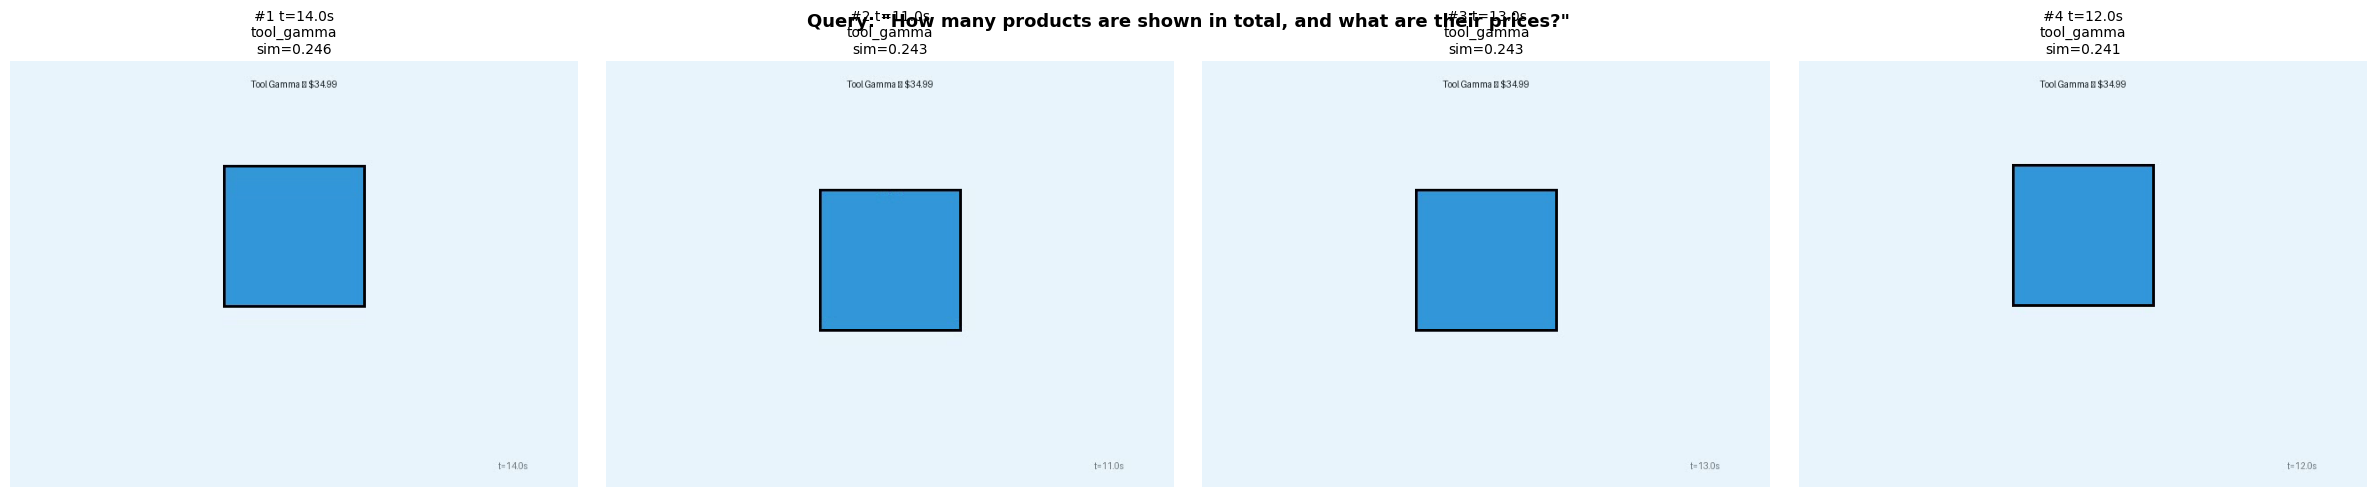


Answer (Ollama/kimi-k2.5:cloud):
Based on the provided frames, only **1 product** is shown:

**Tool Gamma** (blue square) — **$34.99**

All four frames show the same product from the same scene ("tool_gamma") between timestamps 11.0s and 14.0s. Since I only have access to these specific frames from the video, I cannot determine if there are additional products shown elsewhere in the full video.

WITHOUT RAG:
  [Gemini] unavailable, trying next...
  [Response from Ollama / kimi-k2.5:cloud]

Answer (Ollama/kimi-k2.5:cloud):
I don't see any image or product listing attached to your message. Could you please:

1. **Upload a screenshot or image** of the products you're referring to, or
2. **Describe the products** (e.g., name, description, where you saw them)

Once you provide the image or details, I'll be happy to count the total number of products and list their prices for you!


In [12]:
# Change this to any question about the product showcase video
my_question = "How many products are shown in total, and what are their prices?"

if has_llm_provider():
    print(f"Question: {my_question}\n")

    print("=" * 60)
    print("WITH VIDEO RAG:")
    print("=" * 60)
    try:
        answer, retrieved, provider = answer_with_video_rag(my_question, top_k=4)
        show_retrieved_frames(my_question, retrieved)
        print(f"\nAnswer ({provider}):\n{answer}")
    except Exception as e:
        print(f"Error: {e}")

    print("\n" + "=" * 60)
    print("WITHOUT RAG:")
    print("=" * 60)
    try:
        answer_direct, prov_direct = generate_answer_without_rag(my_question)
        print(f"\nAnswer ({prov_direct}):\n{answer_direct}")
    except Exception as e:
        print(f"Error: {e}")
else:
    print("No LLM API key configured. Set at least one API key in Colab Secrets.")

## 10) Teaching Notes and Exercises

**Key takeaways:**
- **Video RAG = frame extraction + Image RAG + temporal metadata.** The video is decomposed into keyframes that are indexed and retrieved just like static images.
- **Timestamps add a temporal dimension** that Image RAG lacks — answers can reference *when* in the video something occurs.
- **Frame sampling rate** is a key design choice: too sparse and you miss content; too dense and you waste compute and storage.
- The same **CLIP + multimodal LLM** stack from Image RAG works here — the main new component is the frame extraction step.
- **Without-RAG comparison** is especially stark for video: the LLM has never seen the video, so it either refuses or hallucinates.

**Exercises:**
- Download a short YouTube clip (e.g., a product review) and replace the synthetic video. How does CLIP handle real-world video frames?
- Experiment with different frame sampling rates (0.5s, 2s, 5s) and measure the impact on retrieval accuracy.
- Add **scene change detection** instead of fixed-interval sampling — extract frames only when the visual content changes significantly.
- Combine video frames with **audio transcription** (e.g., Whisper) for a multimodal RAG that uses both visual and spoken content.
- Discuss: In what business scenarios is Video RAG most valuable? (e.g., surveillance review, training video search, meeting recording Q&A, sports analytics)